In [ ]:
import pandas as pd
import numpy as np
import torch
import warnings
import matplotlib.pyplot as plt
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, TQDMProgressBar
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import CrossEntropy
from sklearn.metrics import classification_report, accuracy_score

# --- 1. DATA LOADING & TARGETING ---
df = pd.read_csv('data/MSFT_preprocessed_data.csv')
df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

# Feature Selection: Baseline (Only OHLCV)
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Target: 1 if the NEXT minute's candle is green (Next Close > Next Open)
# This aligns with slippage execution: Signal at T, Buy at T+1 Open, Sell at T+1 Close
df['Target'] = (df['Close'].shift(-1) > df['Open'].shift(-1)).astype(int)

# Time features are always known
minutes_since_midnight = df['Stock_Timestamp'].dt.hour * 60 + df['Stock_Timestamp'].dt.minute
df['Time_Sin'] = np.sin(2 * np.pi * minutes_since_midnight / 1440)
df['Time_Cos'] = np.cos(2 * np.pi * minutes_since_midnight / 1440)

df['time_idx'] = df.index
df['symbol'] = "MSFT" 
df = df.dropna().reset_index(drop=True)
df['time_idx'] = df.index 

# --- 2. TFT DATASET CREATION ---
max_prediction_length = 1 
max_encoder_length = 60   # Look back 60 minutes

total_len = len(df)
train_cutoff = df["time_idx"].iloc[int(total_len * 0.7)]
val_cutoff = df["time_idx"].iloc[int(total_len * 0.9)]

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= train_cutoff],
    time_idx="time_idx",
    target="Target",
    group_ids=["symbol"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["symbol"],
    time_varying_known_reals=["Time_Sin", "Time_Cos"],
    time_varying_unknown_reals=features, # Only OHLCV
    target_normalizer=None, 
    scalers={f: GroupNormalizer() for f in features},
    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df[lambda x: (x.time_idx > train_cutoff) & (x.time_idx <= val_cutoff)], predict=False)
testing = TimeSeriesDataSet.from_dataset(training, df[lambda x: x.time_idx > val_cutoff], predict=False)

train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)
test_loader = testing.to_dataloader(train=False, batch_size=64, num_workers=0)

In [2]:
# --- 3. MODEL INITIALIZATION ---
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,     
    attention_head_size=4,
    dropout=0.1,
    loss=CrossEntropy(),
    output_size=2 # Binary classification (Down=0, Up=1)
)

# --- 4. TRAINING ---
trainer = Trainer(
    max_epochs=20,
    accelerator="cpu", # Use "gpu" if available
    devices=1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5)],
    gradient_clip_val=0.1,
)

trainer.fit(tft, train_loader, val_loader)
best_model_path = trainer.checkpoint_callback.best_model_path

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ CrossEntropy                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    144 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  2.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     66 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 65.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 65.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 343                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.p
y:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\trainer\connectors\data_connector.p
y:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value 
of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.

In [3]:
# --- 5. STATISTICAL PERFORMANCE ---
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
raw_predictions = best_tft.predict(test_loader, mode="raw", return_y=True, return_x=True)

y_pred = raw_predictions.output.prediction.argmax(dim=-1).flatten().numpy()
y_true = raw_predictions.y[0].flatten().numpy()

print("\n" + "="*50)
print("       TFT BASELINE STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels


       TFT BASELINE STATISTICAL PERFORMANCE
Test Accuracy: 49.79%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.50      0.78      0.61      4490
       Up (1)       0.49      0.21      0.29      4448

     accuracy                           0.50      8938
    macro avg       0.49      0.50      0.45      8938
 weighted avg       0.49      0.50      0.45      8938




       TFT BASELINE FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Net Profit/Loss:         $-777.47
Final Account Capital:   $9,222.53
Total ROI:               -7.77%


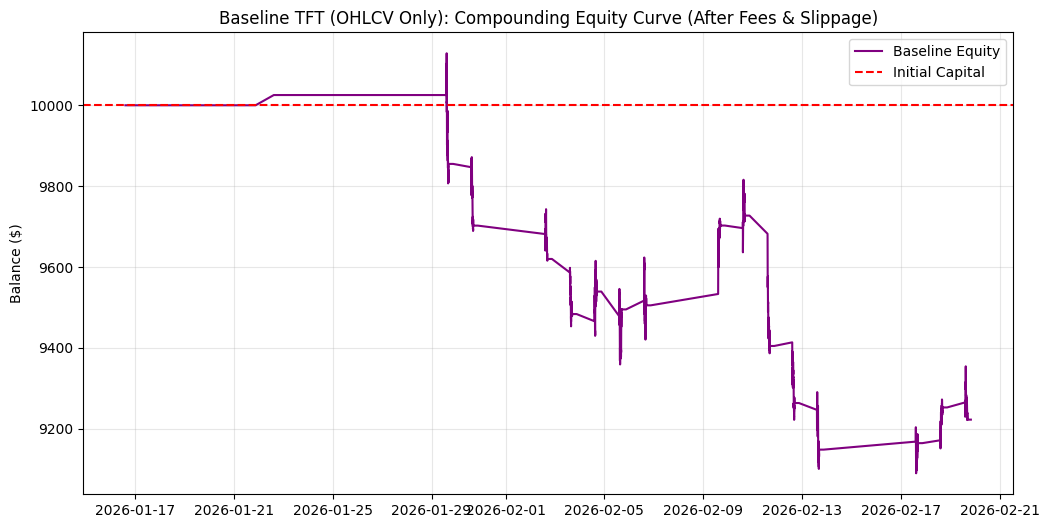

In [4]:
# --- 6. FINANCIAL PERFORMANCE ---
time_indices = raw_predictions.x['decoder_time_idx'].flatten().numpy()
sim_df = df.iloc[time_indices].copy()
sim_df['Signal'] = y_pred

# SLIPPAGE MODELING:
# Decision at T -> Entry at T+1 Open -> Exit at T+1 Close
sim_df['Entry_Price'] = sim_df['Open'].shift(-1)
sim_df['Exit_Price'] = sim_df['Close'].shift(-1)
sim_df = sim_df.dropna(subset=['Entry_Price', 'Exit_Price'])

INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009 
current_capital = INITIAL_CAPITAL
capital_history = []

for idx, row in sim_df.iterrows():
    if row['Signal'] == 1:
        # Calculate shares (compounding capital)
        shares = np.floor(current_capital / row['Entry_Price'])
        
        # Net Profit = (Price Change * Shares) - (Cost * Shares)
        gross_pnl = (row['Exit_Price'] - row['Entry_Price']) * shares
        fees = shares * FEE_PER_SHARE
        
        current_capital += (gross_pnl - fees)
    
    capital_history.append(current_capital)

sim_df['Account_Balance'] = capital_history
profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("       TFT BASELINE FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Net Profit/Loss:         ${profit:,.2f}")
print(f"Final Account Capital:   ${current_capital:,.2f}")
print(f"Total ROI:               {(profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

# --- 7. EQUITY CURVE PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(sim_df['Stock_Timestamp'], sim_df['Account_Balance'], color='purple', label='Baseline Equity')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title('Baseline TFT (OHLCV Only): Compounding Equity Curve (After Fees & Slippage)')
plt.ylabel('Balance ($)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()